# Movement Regularity — Kinematic Axis (HSI 1.3)

Continuous `movement_regularity` score for the `kinematic` domain: how repeating / steady the motion is in a short window.

## Overview
- Objective: a continuous regularity score in [0, 1] (higher = more regular), not a category.
- Method: unbiased autocorrelation of the acceleration magnitude, read at the first dominant peak (step-regularity index Ad1), per Moe-Nilssen & Helbostad, *Gait & Posture* 2004. Reference implementations: Frontiers knee-osteoarthritis gait study; PMC3231731 (real-time 50 Hz gait regularity).
- Feature is the magnitude sqrt(x^2 + y^2 + z^2), not per-axis: a deliberate orientation-invariance choice, deviating from the per-axis clinical standard.
- Unbiased estimator (each lag normalized by its overlap count), not the biased `np.correlate` output, because the stride lag exceeds the step lag.
- Movement (std of magnitude) is a validity gate, not a category: below a floor the autocorrelation is near-noise and the score is unreliable.
- Sampling 50 Hz, 5 s window. Dataset: PAMAP2 chest IMU (trunk proxy), downsampled from 100 Hz.
- Scope of this notebook: compute the score and show it across activities. Confidence calibration, HSI emission, and formal validation are later loops.

## 1. Setup and configuration
Imports and all constants in one place.

In [13]:
import re, glob, json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

mpl.rcParams.update({
    "figure.figsize": (7.5, 5.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "font.size": 11,
    "legend.fontsize": 10,
})

In [14]:
# Sampling and windowing
SOURCE_RATE = 100                    # PAMAP2 IMU rate (Hz)
SAMPLE_RATE = 50                     # target rate (matches activity_state)
DECIM = SOURCE_RATE // SAMPLE_RATE   # decimation factor (100 -> 50 Hz)
WINDOW_SEC = 5.0                     # window length (~5 strides; literature-justified for regularity)
WINDOW = int(WINDOW_SEC * SAMPLE_RATE)   # 250 samples
STEP = WINDOW // 2                   # 50% overlap

# Autocorrelation period band (lags in samples at SAMPLE_RATE)
LAG_MIN = 10                         # 0.20 s, fastest plausible step period
LAG_MAX = 100                        # 2.00 s, slowest plausible period
PEAK_PROMINENCE = 0.05               # minimum prominence for a dominant autocorrelation peak

# Validity gates
MOVEMENT_FLOOR = 0.5                 # PROVISIONAL (m/s^2): below this, motion is near-noise -> regularity unreliable
ACC_MAX = 16 * 9.81                  # sensor range (+/-16 g); |accel| beyond this is an impossible spike
MAX_BAD_FRAC = 0.5                   # window with more than half bad samples -> uncertain

# Confidence (deterministic; trust in the estimate, separate from the score)
MIN_CYCLES = 7.0                     # minimum detected periods to estimate (~3.5 gait strides; the dominant peak is the step)
SAT_CYCLES = 10.0                    # cycle count at which cycle-adequacy confidence saturates (~5 strides)
PROM_FULL = 1.5                      # dominant-peak prominence giving full prominence confidence (clean-gait level)

# Held-out subjects for the sanity check (the confidence constants were informed by subjects 101-103)
SANITY_SUBJECTS = {104, 105, 106, 107, 108, 109}

# PAMAP2 chest (trunk) accelerometer (+/-16 g): columns in the .dat file
CHEST_ACC = [21, 22, 23]             # trunk proxy, matching the trunk placement of the reference method
ACTIVITY_NAMES = {1: "lying", 2: "sitting", 3: "standing", 4: "walking", 5: "running", 6: "cycling",
                  7: "nordic_walk", 12: "ascend_stairs", 13: "descend_stairs", 16: "vacuum",
                  17: "ironing", 24: "rope_jump"}

PAMAP2_GLOB = "/home/voare/Documents/Synheart/Kinematics/Dataset/PAMAP2_data/PAMAP2_Dataset/Protocol/*.dat"

## 2. Signal cleaning and validity gate
Magnitude with impossible-spike and gap handling (causal forward-fill); movement floor and broken-window gates.

In [15]:
def fill_gaps(mag, bad):
    """Hold the last good value over bad samples (causal: never looks ahead)."""
    mag = mag.copy()
    for i in range(1, len(mag)):
        if bad[i]:
            mag[i] = mag[i-1]
    return mag

def window_features(xyz):
    """Return (movement, regularity, dominant lag, peak prominence, flag) for one window (samples, 3)."""
    mag = np.sqrt((xyz ** 2).sum(axis=1))
    bad = np.isnan(mag) | (mag > ACC_MAX)             # missing sample or impossible spike
    if bad.mean() > MAX_BAD_FRAC or bad[0]:           # too broken / no valid start value
        return np.nan, np.nan, np.nan, np.nan, "uncertain"
    mag = fill_gaps(mag, bad)
    movement = float(mag.std())
    score, lag, prom = regularity_detail(mag)
    flag = "ok" if movement >= MOVEMENT_FLOOR else "low_movement"   # gate near-noise windows
    return movement, score, lag, prom, flag

## 3. Regularity feature (Moe-Nilssen unbiased autocorrelation)
Unbiased autocorrelation of the mean-removed magnitude, normalized by the zero-lag coefficient, read at the first dominant peak.

In [16]:
def regularity_detail(mag):
    """Return (score, dominant-period lag, peak prominence) for one window.

    score = unbiased autocorrelation coefficient at the first dominant peak, in [0, 1].
    """
    x = mag - mag.mean()
    n = len(x)
    # UNBIASED estimator: divide each lag by its overlap count (n - lag), not np.correlate's biased sum.
    ac = np.correlate(x, x, mode="full")[n-1:n+LAG_MAX] / (n - np.arange(LAG_MAX + 1))
    if ac[0] <= 0:
        return np.nan, np.nan, np.nan
    ac = ac / ac[0]                                   # normalize by the zero-lag coefficient
    peaks, props = find_peaks(ac, prominence=PEAK_PROMINENCE)
    keep = (peaks >= LAG_MIN) & (peaks <= LAG_MAX)
    peaks, proms = peaks[keep], props["prominences"][keep]
    if len(peaks) == 0:
        return 0.0, np.nan, 0.0                       # no dominant period -> minimal regularity
    lag = int(peaks[0])
    return float(np.clip(ac[lag], 0.0, 1.0)), lag, float(proms[0])

def regularity(mag):
    """Step-regularity score in [0, 1] (the coefficient at the first dominant peak)."""
    return regularity_detail(mag)[0]

## 4. PAMAP2 loader
Downsample 100 -> 50 Hz, window within each activity run (no mixing across activities), keep subject id for later subject-independent splits.

In [17]:
# Decimation by slicing: the gait fundamental (~1-4 Hz) is far below the 25 Hz Nyquist, so no anti-alias filter is needed.
rows = []
for path in sorted(glob.glob(PAMAP2_GLOB)):
    subj = int(re.search(r"subject(\d+)", path).group(1))
    raw = pd.read_csv(path, sep=r"\s+", header=None, usecols=[1] + CHEST_ACC)
    act = raw[1].to_numpy()[::DECIM]
    xyz = raw[CHEST_ACC].to_numpy()[::DECIM]
    change = np.where(np.diff(act) != 0)[0] + 1       # activity boundaries
    for s0, e0 in zip(np.r_[0, change], np.r_[change, len(act)]):
        a = act[s0]
        if a not in ACTIVITY_NAMES:                   # skip transient (0) and non-protocol labels
            continue
        for s in range(s0, e0 - WINDOW + 1, STEP):    # windows within ONE activity
            mv, score, lag, prom, flag = window_features(xyz[s:s+WINDOW])
            rows.append((subj, ACTIVITY_NAMES[a], mv, score, lag, prom, flag))
reg = pd.DataFrame(rows, columns=["subject", "activity", "movement", "regularity", "dom_lag", "peak_prom", "flag"])
print(f"windows: {len(reg)}  |  subjects: {sorted(map(int, reg['subject'].unique()))}")
print(reg["flag"].value_counts().to_string())

windows: 7612  |  subjects: [101, 102, 103, 104, 105, 106, 107, 108, 109]
flag
ok              4440
low_movement    3164
uncertain          8


## 5. Regularity across activities

In [18]:
ok = reg[reg["flag"] == "ok"]
summary = (ok.groupby("activity")["regularity"].agg(["count", "median", "mean"]).round(3)
             .sort_values("median", ascending=False))
print("Regularity per activity (valid windows):")
print(summary.to_string())

Regularity per activity (valid windows):
                count  median   mean
activity                            
running           372   0.938  0.915
nordic_walk       727   0.931  0.913
walking           931   0.929  0.827
rope_jump         180   0.738  0.583
ascend_stairs     430   0.723  0.668
descend_stairs    378   0.560  0.541
cycling           634   0.313  0.314
standing           36   0.228  0.265
ironing            56   0.144  0.164
sitting            48   0.119  0.170
lying              55   0.089  0.123
vacuum            593   0.065  0.107


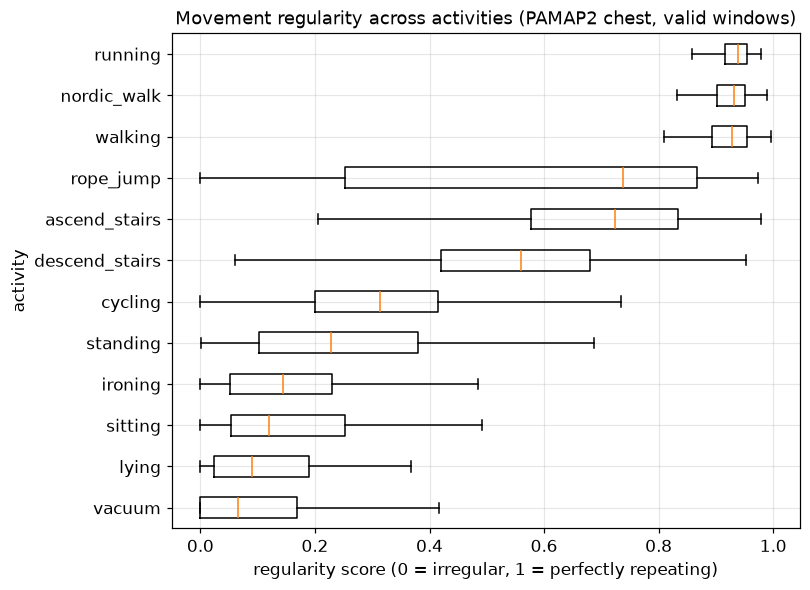

In [19]:
order = ok.groupby("activity")["regularity"].median().sort_values().index.tolist()
data = [ok.loc[ok["activity"] == a, "regularity"].dropna().to_numpy() for a in order]
plt.figure(figsize=(7.5, 5.5))
plt.boxplot(data, orientation="horizontal", tick_labels=order, showfliers=False)
plt.xlabel("regularity score (0 = irregular, 1 = perfectly repeating)")
plt.ylabel("activity")
plt.title("Movement regularity across activities (PAMAP2 chest, valid windows)")
plt.tight_layout(); plt.show()

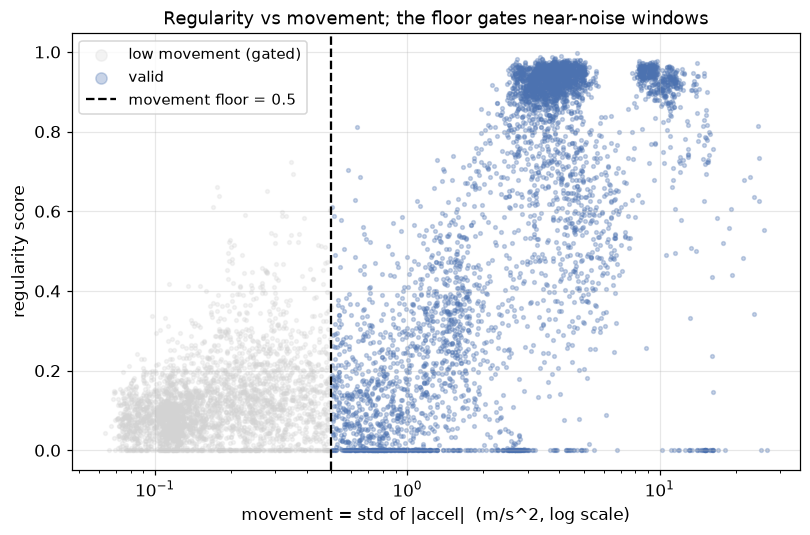

In [20]:
gated = reg[reg["flag"] == "low_movement"]
plt.figure(figsize=(7.5, 5))
plt.scatter(gated["movement"], gated["regularity"], s=6, alpha=0.25, color="lightgray", label="low movement (gated)")
plt.scatter(ok["movement"], ok["regularity"], s=6, alpha=0.30, color="#4C72B0", label="valid")
plt.axvline(MOVEMENT_FLOOR, ls="--", color="black", label=f"movement floor = {MOVEMENT_FLOOR}")
plt.xscale("log")
plt.xlabel("movement = std of |accel|  (m/s^2, log scale)")
plt.ylabel("regularity score")
plt.title("Regularity vs movement; the floor gates near-noise windows")
plt.legend(markerscale=3)
plt.tight_layout(); plt.show()

## 6. Validation — Part A: synthetic floor
Estimator behaviour on signals with known regularity, independent of any dataset: pure sinusoids (expect ~1), pure noise (expect ~0), and a sine-plus-noise SNR sweep.

A1  pure sine (expect ~1.0):
     1.0 Hz : 1.000
     1.5 Hz : 0.997
     2.0 Hz : 1.000
     2.5 Hz : 1.000
     3.0 Hz : 0.992
A2  pure noise (expect ~0): mean 0.064, 95th pct 0.125
A3  SNR sweep (2 Hz sine + noise):
     SNR   17.0 dB : 0.980
     SNR   11.0 dB : 0.927
     SNR    6.1 dB : 0.804
     SNR    3.0 dB : 0.665
     SNR    0.1 dB : 0.480
     SNR   -3.0 dB : 0.214
     SNR   -5.9 dB : 0.059
     SNR   -9.0 dB : 0.026
     SNR  -12.6 dB : 0.031
     SNR  -15.1 dB : 0.046


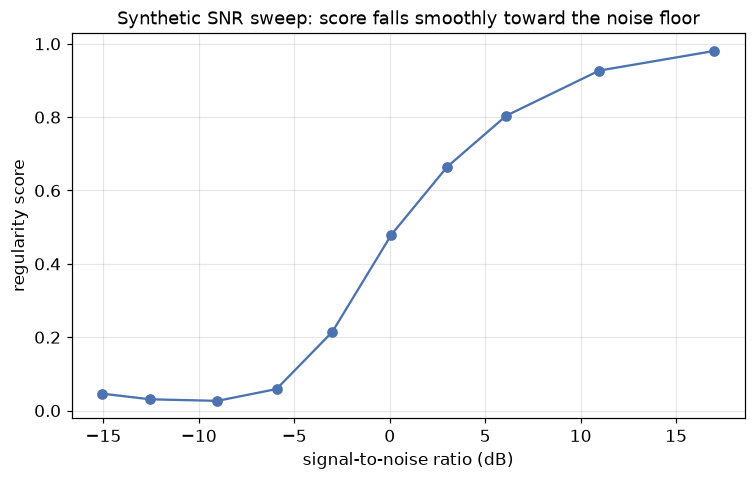

In [21]:
N_TRIALS = 100
rng_synth = np.random.default_rng(0)
t = np.arange(WINDOW) / SAMPLE_RATE

# A1: pure sinusoids at gait frequencies -> regularity should be ~1.0
print("A1  pure sine (expect ~1.0):")
for f in [1.0, 1.5, 2.0, 2.5, 3.0]:
    s = np.mean([regularity(np.sin(2*np.pi*f*t + rng_synth.uniform(0, 2*np.pi))) for _ in range(N_TRIALS)])
    print(f"     {f:>3} Hz : {s:.3f}")

# A2: pure Gaussian noise -> regularity should be ~0
noise_scores = [regularity(rng_synth.standard_normal(WINDOW)) for _ in range(N_TRIALS)]
print(f"A2  pure noise (expect ~0): mean {np.mean(noise_scores):.3f}, 95th pct {np.percentile(noise_scores, 95):.3f}")

# A3: 2 Hz sine + increasing noise -> score should fall as SNR drops
noise_levels = np.array([0.1, 0.2, 0.35, 0.5, 0.7, 1.0, 1.4, 2.0, 3.0, 4.0])
snr_db = 10 * np.log10(0.5 / noise_levels**2)                 # sine power 0.5, noise power = level^2
sweep = np.array([np.mean([regularity(np.sin(2*np.pi*2*t + rng_synth.uniform(0, 2*np.pi)) + ns*rng_synth.standard_normal(WINDOW))
                           for _ in range(N_TRIALS)]) for ns in noise_levels])
print("A3  SNR sweep (2 Hz sine + noise):")
for sd, sc in zip(snr_db, sweep):
    print(f"     SNR {sd:6.1f} dB : {sc:.3f}")

plt.figure(figsize=(7, 4.5))
plt.plot(snr_db, sweep, "o-", color="#4C72B0")
plt.xlabel("signal-to-noise ratio (dB)")
plt.ylabel("regularity score")
plt.title("Synthetic SNR sweep: score falls smoothly toward the noise floor")
plt.tight_layout(); plt.show()

## 7. Validation — Part B: discriminative validity on PAMAP2
Known-rhythmic vs known-irregular separation across subjects. Ambiguous activities are shown but not scored. Uses windows with a defined score (flag != uncertain).

In [22]:
RHYTHMIC  = {"walking", "running", "nordic_walk"}
IRREGULAR = {"vacuum", "ironing", "sitting", "lying", "standing"}
AMBIGUOUS = {"cycling", "ascend_stairs", "descend_stairs", "rope_jump"}
GROUP = {**{a: "rhythmic" for a in RHYTHMIC}, **{a: "irregular" for a in IRREGULAR}, **{a: "ambiguous" for a in AMBIGUOUS}}

scored = reg[reg["flag"] != "uncertain"].dropna(subset=["regularity"]).copy()
scored["group"] = scored["activity"].map(GROUP)

dist = scored.groupby("activity")["regularity"].describe(percentiles=[.25, .5, .75])[["count", "25%", "50%", "75%"]].round(3)
dist["group"] = [GROUP[a] for a in dist.index]
print("Per-activity regularity distribution (scored windows):")
print(dist.sort_values("50%", ascending=False).to_string())

pair = scored[scored["activity"].isin(RHYTHMIC | IRREGULAR)].copy()
pair["y"] = pair["activity"].isin(RHYTHMIC).astype(int)
auc = roc_auc_score(pair["y"], pair["regularity"])
_, pval = mannwhitneyu(pair.loc[pair.y == 1, "regularity"], pair.loc[pair.y == 0, "regularity"], alternative="greater")
print(f"\nRhythmic vs irregular ({len(pair)} windows): "
      f"ROC-AUC = {auc:.3f}, rank-biserial effect = {2*auc - 1:.3f}, Mann-Whitney p = {pval:.1e}")

per_subj = [(int(sid), len(sg), round(roc_auc_score(sg["y"], sg["regularity"]), 3))
            for sid, sg in pair.groupby("subject") if sg["y"].nunique() == 2]
per_subj = pd.DataFrame(per_subj, columns=["subject", "n", "auc"])
print("\nPer-subject AUC (subject-independent stability):")
print(per_subj.to_string(index=False))
print(f"min {per_subj.auc.min():.3f} | median {per_subj.auc.median():.3f} | "
      f"max {per_subj.auc.max():.3f} | subjects >= 0.9: {(per_subj.auc >= 0.9).sum()}/{len(per_subj)}")

Per-activity regularity distribution (scored windows):
                count    25%    50%    75%      group
activity                                             
running         384.0  0.912  0.938  0.954   rhythmic
nordic_walk     741.0  0.900  0.931  0.951   rhythmic
walking         942.0  0.892  0.928  0.953   rhythmic
rope_jump       188.0  0.150  0.730  0.863  ambiguous
ascend_stairs   445.0  0.545  0.715  0.831  ambiguous
descend_stairs  394.0  0.402  0.549  0.678  ambiguous
cycling         647.0  0.196  0.307  0.410  ambiguous
standing        748.0  0.065  0.118  0.191  irregular
ironing         942.0  0.054  0.116  0.182  irregular
sitting         729.0  0.061  0.104  0.164  irregular
lying           756.0  0.043  0.075  0.113  irregular
vacuum          688.0  0.000  0.066  0.166  irregular

Rhythmic vs irregular (5930 windows): ROC-AUC = 0.949, rank-biserial effect = 0.897, Mann-Whitney p = 0.0e+00

Per-subject AUC (subject-independent stability):
 subject   n   auc
     101 

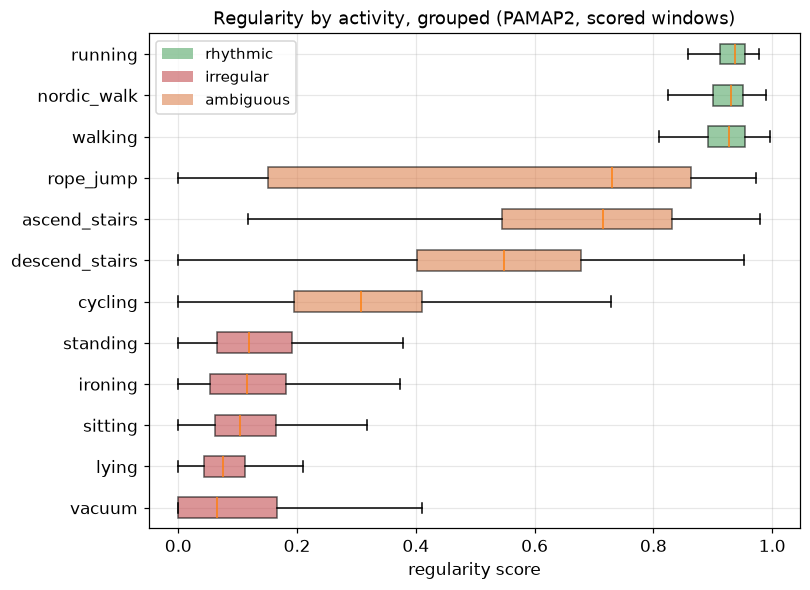

In [23]:
group_color = {"rhythmic": "#55A868", "irregular": "#C44E52", "ambiguous": "#DD8452"}
order = scored.groupby("activity")["regularity"].median().sort_values().index.tolist()
data = [scored.loc[scored["activity"] == a, "regularity"].to_numpy() for a in order]
fig, ax = plt.subplots(figsize=(7.5, 5.5))
bp = ax.boxplot(data, orientation="horizontal", tick_labels=order, showfliers=False, patch_artist=True)
for patch, a in zip(bp["boxes"], order):
    patch.set_facecolor(group_color[GROUP[a]]); patch.set_alpha(0.6)
ax.set_xlabel("regularity score")
ax.set_title("Regularity by activity, grouped (PAMAP2, scored windows)")
ax.legend(handles=[Patch(facecolor=c, alpha=0.6, label=g) for g, c in group_color.items()])
plt.tight_layout(); plt.show()

## 8. Front-end consistency audit (vs activity_state)
All four kinematic states are intended to deploy from one phone accelerometer in one pocket. This logs front-end divergences only; nothing is changed.

In [24]:
audit = pd.DataFrame([
    ["sampling rate",        "50 Hz",                                    "50 Hz",                            "yes", "matched"],
    ["window length",        "5 s (250 samples)",                        "2.56 s (128 samples)",             "no",  "justified: ~5 strides required for stride regularity"],
    ["overlap",              "50%",                                      "50%",                              "yes", "matched"],
    ["placement / sensor",   "chest IMU (trunk proxy)",                  "phone, front pocket / waist",      "no",  "debt: chest is a clinical proxy; pocket validation pending"],
    ["gravity handling",     "raw magnitude; per-window mean removal",   "Butterworth 0.3 Hz gravity split", "no",  "debt: should consume the same body-accel magnitude on unified data"],
    ["feature domain",       "magnitude sqrt(x^2+y^2+z^2)",              "magnitude sqrt(x^2+y^2+z^2)",      "yes", "both orientation-invariant"],
    ["NaN / spike handling", "forward-fill (causal), >half-bad uncertain", "none (clean datasets)",          "no",  "justified: live-stream robustness, not yet ported to activity_state"],
    ["movement units",       "m/s^2 (PAMAP2 raw)",                       "g (gravity-removed)",              "no",  "debt: MOVEMENT_FLOOR scale differs; reconcile on unified pocket data"],
], columns=["config item", "movement_regularity", "activity_state", "matches", "note"])
print(audit.to_string(index=False))

         config item                        movement_regularity                   activity_state matches                                                                 note
       sampling rate                                      50 Hz                            50 Hz     yes                                                              matched
       window length                          5 s (250 samples)             2.56 s (128 samples)      no                 justified: ~5 strides required for stride regularity
             overlap                                        50%                              50%     yes                                                              matched
  placement / sensor                    chest IMU (trunk proxy)      phone, front pocket / waist      no           debt: chest is a clinical proxy; pocket validation pending
    gravity handling     raw magnitude; per-window mean removal Butterworth 0.3 Hz gravity split      no   debt: should consume th

### Findings
- **Part A (synthetic floor):** pure sinusoids at gait frequencies score ~1.0 and pure noise ~0.07; the score falls smoothly with decreasing SNR and asymptotes to the noise floor. The estimator is sound and dataset-independent.
- **Part B (discriminative validity):** rhythmic activities score well above irregular ones (ROC-AUC 0.95 pooled; per-subject AUC median 0.99, 7/8 subjects >= 0.9). The rank-ordering is stable subject-to-subject; subject 106 is the single weak case (AUC ~0.70). Ambiguous activities (cycling, stairs, rope jumping) sit between the two groups as expected.
- **Part C (front-end audit):** front ends match on sampling rate (50 Hz), overlap (50%), and magnitude features. The 5 s window is a justified divergence (≈5 strides are physically required for stride regularity). Convergence debt, to reconcile on unified pocket data: chest vs pocket placement, gravity handling, and `MOVEMENT_FLOOR` units/scale.
- Chest IMU is a clinical proxy for the trunk; pocket-placement validation remains a known gap and `MOVEMENT_FLOOR` is provisional. Not addressed in this loop.

## 9. Confidence (deterministic)
Trust in each estimate, separate from the score: cycle adequacy (clean periods in the window) and dominant-peak prominence, combined into [0, 1]. This is not a probability and does not measure how regular the motion is.

In [25]:
def confidence(n_cycles, prominence):
    """Estimate trust in [0, 1] = geometric mean of cycle adequacy and peak prominence."""
    cyc = np.clip((n_cycles - MIN_CYCLES) / (SAT_CYCLES - MIN_CYCLES), 0.0, 1.0)   # >= MIN_CYCLES periods present
    prm = np.clip(prominence / PROM_FULL, 0.0, 1.0)                                 # tall, sharp dominant peak
    return float(np.sqrt(cyc * prm))                                                # both must be adequate

# Per-window emission decision: valid score, or null with a reason.
reg["n_cycles"] = WINDOW / reg["dom_lag"]                          # detected periods in the window
reason = np.select(
    [reg["flag"] == "uncertain",
     reg["flag"] == "low_movement",
     reg["n_cycles"].fillna(0) < MIN_CYCLES],
    ["window_unreliable", "low_movement", "insufficient_cycles"],
    default="valid")
reg["reason"] = reason
cyc = np.clip((reg["n_cycles"] - MIN_CYCLES) / (SAT_CYCLES - MIN_CYCLES), 0.0, 1.0)
prm = np.clip(reg["peak_prom"] / PROM_FULL, 0.0, 1.0)
reg["confidence"] = np.where(reg["reason"] == "valid", np.sqrt(cyc * prm), np.nan)

print("emission outcome per window:")
print(reg["reason"].value_counts().to_string())
print()
print("median confidence of valid readings by activity:")
print(reg[reg["reason"] == "valid"].groupby("activity")["confidence"].median().round(3).sort_values(ascending=False).to_string())

emission outcome per window:
reason
valid                  4226
low_movement           3164
insufficient_cycles     214
window_unreliable         8

median confidence of valid readings by activity:
activity
running           1.000
walking           0.868
rope_jump         0.853
descend_stairs    0.809
nordic_walk       0.802
ascend_stairs     0.655
cycling           0.599
standing          0.545
ironing           0.419
lying             0.342
sitting           0.335
vacuum            0.289


## 10. HSI emission
Continuous reading: `name`, real `score`, `direction="higher_is_more"`, deterministic `confidence`. Invalid windows emit a null reading with a reason. Single-modality: no `modalities_used`, no `confidence_breakdown`, no raw features.

In [26]:
def hsi_reading(score, conf):
    """HSI 1.3 continuous kinematic reading for movement_regularity."""
    return {"name": "movement_regularity", "score": round(float(score), 3), "direction": "higher_is_more",
            "confidence": round(float(conf), 3), "inference_mode": "deterministic_rule",
            "model_id": "rulepack://movement_regularity_v1"}

def hsi_null(reason):
    """Null reading: regularity is undefined for this window."""
    return {"name": "movement_regularity", "score": None, "direction": "higher_is_more",
            "confidence": None, "reason": reason, "inference_mode": "deterministic_rule",
            "model_id": "rulepack://movement_regularity_v1"}

def emit(row):
    if row["reason"] == "valid":
        return hsi_reading(row["regularity"], row["confidence"])
    return hsi_null(row["reason"])

readings = [emit(r) for _, r in reg.iterrows()]
print(f"emitted {len(readings)} readings ({(reg['reason'] == 'valid').sum()} valid, {(reg['reason'] != 'valid').sum()} null)")
valid_example = reg[reg["reason"] == "valid"].sort_values("confidence", ascending=False).iloc[0]
null_example = reg[reg["reason"] == "low_movement"].iloc[0]
print()
print("valid example:")
print(json.dumps(emit(valid_example), indent=2))
print()
print("null example:")
print(json.dumps(emit(null_example), indent=2))

emitted 7612 readings (4226 valid, 3386 null)

valid example:
{
  "name": "movement_regularity",
  "score": 0.905,
  "direction": "higher_is_more",
  "confidence": 1.0,
  "inference_mode": "deterministic_rule",
  "model_id": "rulepack://movement_regularity_v1"
}

null example:
{
  "name": "movement_regularity",
  "score": null,
  "direction": "higher_is_more",
  "confidence": null,
  "reason": "low_movement",
  "inference_mode": "deterministic_rule",
  "model_id": "rulepack://movement_regularity_v1"
}


## 11. Sanity check (not calibration)
On held-out subjects, confirm that valid high-confidence readings concentrate on steady gait and that nulls / low-confidence concentrate on still and ambiguous activities. Windows are cut within single activities, so no transition windows exist by construction.

In [27]:
held = reg[reg["subject"].isin(SANITY_SUBJECTS)].copy()
held["group"] = held["activity"].map(GROUP)

# per-activity emission composition + median confidence of valid readings
comp = pd.crosstab(held["activity"], held["reason"], normalize="index").round(2)
comp["median_conf_valid"] = held[held["reason"] == "valid"].groupby("activity")["confidence"].median().round(3)
comp["group"] = [GROUP[a] for a in comp.index]
order = comp.sort_values("valid", ascending=False).index
print("Held-out subjects", sorted(SANITY_SUBJECTS), "- emission composition per activity:")
print(comp.loc[order].to_string())

# group-level confidence of valid readings
print()
print("valid-reading confidence by group (held-out):")
print(held[held["reason"] == "valid"].groupby("group")["confidence"].agg(["count", "median"]).round(3).to_string())

Held-out subjects [104, 105, 106, 107, 108, 109] - emission composition per activity:
reason          insufficient_cycles  low_movement  valid  window_unreliable  median_conf_valid      group
activity                                                                                                 
walking                        0.00          0.01   0.99               0.00              0.868   rhythmic
nordic_walk                    0.00          0.01   0.99               0.00              0.802   rhythmic
running                        0.00          0.03   0.97               0.00              1.000   rhythmic
descend_stairs                 0.00          0.04   0.96               0.00              0.811  ambiguous
rope_jump                      0.00          0.03   0.95               0.01              0.766  ambiguous
cycling                        0.10          0.02   0.89               0.00              0.575  ambiguous
ascend_stairs                  0.13          0.04   0.84          

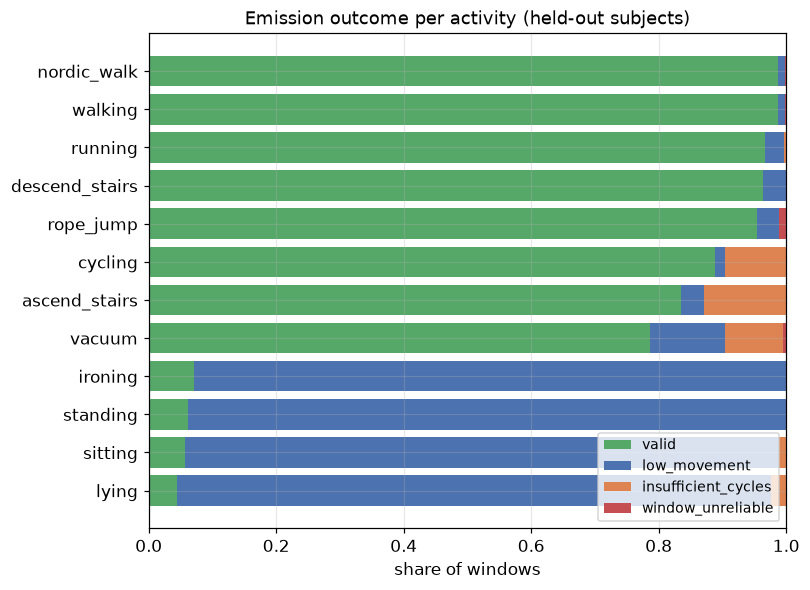

In [28]:
reasons = ["valid", "low_movement", "insufficient_cycles", "window_unreliable"]
reason_color = {"valid": "#55A868", "low_movement": "#4C72B0", "insufficient_cycles": "#DD8452", "window_unreliable": "#C44E52"}
comp_plot = pd.crosstab(held["activity"], held["reason"], normalize="index").reindex(columns=reasons).fillna(0)
order2 = comp_plot["valid"].sort_values().index
fig, ax = plt.subplots(figsize=(7.5, 5.5))
left = np.zeros(len(order2))
for r in reasons:
    vals = comp_plot.loc[order2, r].to_numpy()
    ax.barh(order2, vals, left=left, color=reason_color[r], label=r)
    left += vals
ax.set_xlabel("share of windows")
ax.set_title("Emission outcome per activity (held-out subjects)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

### Findings — confidence and emission
- **No ECE / reliability curve:** there is no ground-truth regularity label, so per-reading probabilistic calibration is not defined. The normalized autocorrelation score is self-describing (closeness to 1 = more regular), and the field establishes reliability at the method level via test-retest ICC (~0.66–0.68 for stride regularity; Moe-Nilssen & Helbostad, *Gait & Posture* 2004), not per reading.
- **Confidence is deterministic**, from cycle adequacy and dominant-peak prominence; it measures trust in the estimate, not how regular the motion is (the score carries that).
- **Null is undefined, not low-confidence:** near-still (`low_movement`), too few cycles (`insufficient_cycles`), and broken windows (`window_unreliable`) emit a null reading with a reason rather than a score.
- **Sanity check (not calibration):** valid high-confidence readings concentrate on steady gait; nulls and low-confidence concentrate on still and ambiguous activities, on held-out subjects.
- **Convergence debt carried forward unchanged:** chest vs pocket placement, gravity handling, and `MOVEMENT_FLOOR` units remain provisional, to reconcile on unified pocket data. Symmetry and step/stride split are out of scope.